# Анализ результатов L-SHADE

Результаты робастной оптимизации управления ветротурбиной методом **L-SHADE**.

Задача состоит в подборе параметров управления pitch angle `beta(v)` и rotor speed `omega(v)` при случайном ветре. Скорость ветра моделируется распределением Weibull, а качество решения оценивается целевой функцией с учетом средней мощности, вариативности мощности, превышения номинальной мощности и штрафов.

Цель анализа: проверить сходимость оптимайзера, работу адаптивных механизмов, уменьшения популяции и физическую интерпретируемость найденного контроллера.

## Импорт и пути к результатам

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

PROJECT_ROOT = Path(r"C:\Users\oljjago\PycharmProjects\PMO_2_2026")
FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "lshade"
SUMMARY_PATH = PROJECT_ROOT / "results" / "summary" / "lshade_summary.json"

assert FIGURES_DIR.exists(), f"Не найдена папка с графиками: {FIGURES_DIR}"
assert SUMMARY_PATH.exists(), f"Не найден summary JSON: {SUMMARY_PATH}"

with SUMMARY_PATH.open("r", encoding="utf-8") as file:
    summary = json.load(file)

def show_png(filename: str, figsize=(10, 5)):
    path = FIGURES_DIR / filename
    assert path.exists(), f"Не найден график: {path}"
    image = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.title(filename)
    plt.show()

def yes_no(value: bool) -> str:
    return "да" if value else "нет"

## Основные численные результаты

In [2]:
checks = summary["validation_checks"]

display(Markdown(f"""
| Метрика | Значение |
|---|---:|
| best_final_J | `{summary['best_final_J']:.6f}` |
| theta_best | `{summary['theta_best']}` |
| runtime_sec | `{summary['runtime_sec']:.3f}` |
| final_population_size | `{summary['final_population_size']}` |
| archive_final_size | `{summary['archive_final_size']}` |
| max_power_MW | `{summary['max_power_MW']:.3f}` |

**Валидационная проверка**

- best_J_nonincreasing: **{yes_no(checks['best_J_nonincreasing'])}**
- diversity_nonzero: **{yes_no(checks['diversity_nonzero'])}**
- archive_used: **{yes_no(checks['archive_used'])}**
- adaptive_updates_present: **{yes_no(checks['adaptive_updates_present'])}**
- final_theta_inside_bounds: **{yes_no(checks['final_theta_inside_bounds'])}**
- power_curve_finite: **{yes_no(checks['power_curve_finite'])}**
"""))


| Метрика | Значение |
|---|---:|
| best_final_J | `-0.289208` |
| theta_best | `[0.0, 1.184524153924608, 0.14878303651045213, 0.011389983571958898, 0.16071947608112824]` |
| runtime_sec | `2.530` |
| final_population_size | `4` |
| archive_final_size | `4` |
| max_power_MW | `5.657` |

**Validation checks**

- best_J_nonincreasing: **да**
- diversity_nonzero: **да**
- archive_used: **да**
- adaptive_updates_present: **да**
- final_theta_inside_bounds: **да**
- power_curve_finite: **да**


## Сходимость целевой функции

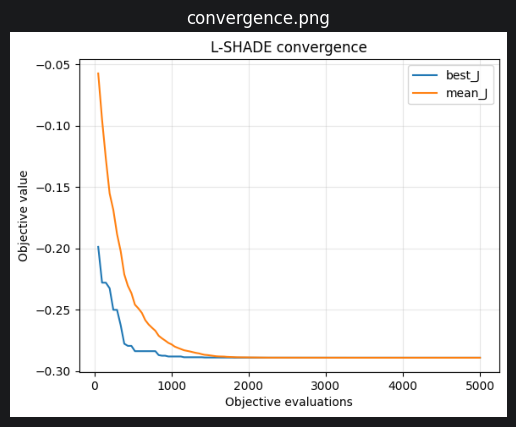

In [3]:
show_png("convergence.png")

Целевая функция быстро улучшается в начале оптимизации, после чего выходит на плато. Среднее значение `mean_J` постепенно приближается к `best_J`, что указывает на сходимость популяций к похожим по качеству решениям.

## Диверсификация попаляций

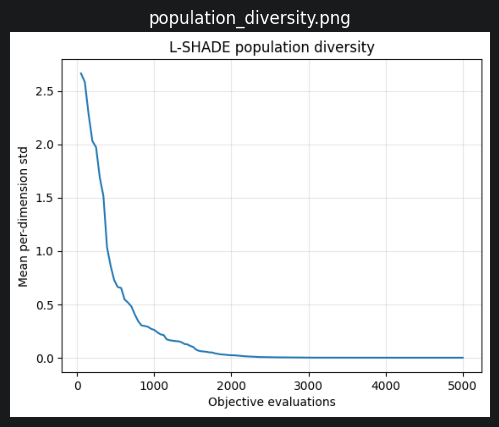

In [4]:
show_png("population_diversity.png")

В начале разнообразие высокая: оптимайзер исследует разные области пространства параметров. Затем популяция постепенно сжимается, и режим exploration сменяется exploitation около найденной перспективной области.

## Линейное уменьшение размера популяций

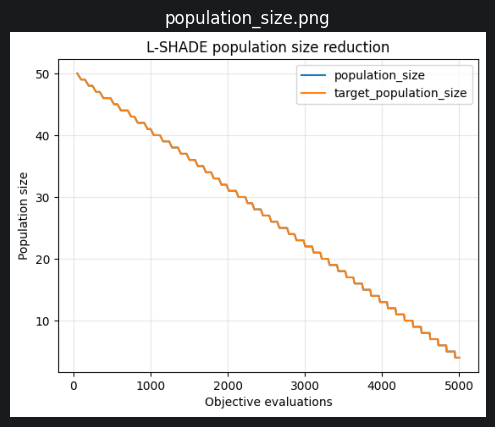

In [5]:
show_png("population_size.png")

L-SHADE линейно уменьшает размер популяции. В начале это дает широкий поиск, а ближе к концу оптимайзер становится более локальной и направленной на тонкую настройку решения.

## Успешные обновления

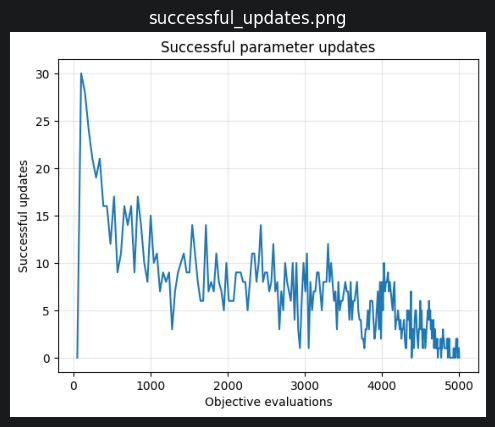

In [6]:
show_png("successful_updates.png")

В начале оптимизации успешных обновлений больше, потому что хорошие направления найти проще. Позже улучшения становятся редкими: алгоритм приближается к оптимуму, и каждое новое улучшение требует более точного шага.

## Adaptive mutation scale F

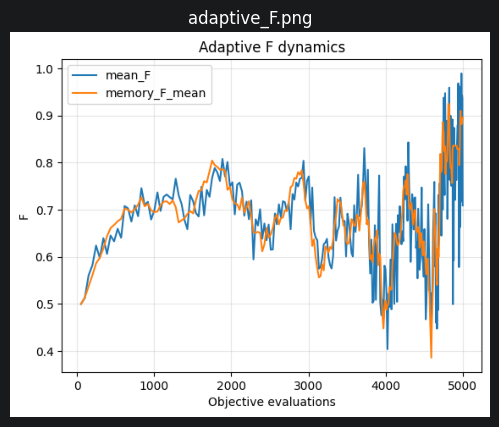

In [7]:
show_png("adaptive_F.png")

Алгоритм адаптирует масштаб мутации `F` по истории успешных шагов. В начале возможны более крупные шаги, а затем поведение становится более локальным и немного шумным, что типично для адаптивной дифференциальной эволюции.

## Адаптивная доля кроссовера  CR

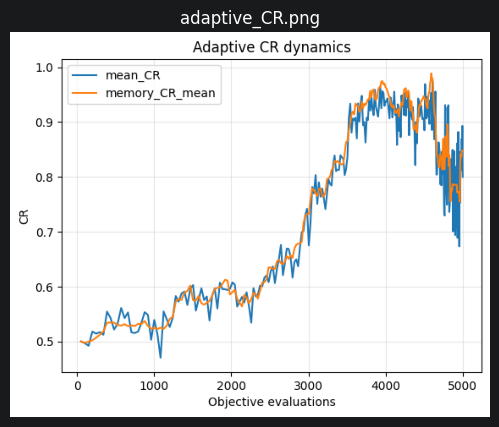

In [8]:
show_png("adaptive_CR.png")

Доля кроссовера постепенно меняется в ходе оптимизации. Увеличение `CR` означает, что алгоритм сильнее доверяет направлению мутаций и чаще переносит компоненты пробного вектора в новое решение.

## Внешний архив

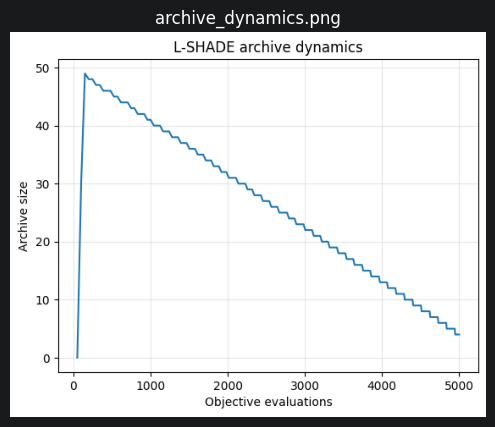

In [9]:
show_png("archive_dynamics.png")

Архив хранит старые решения, вытесненные успешными пробными векторами. Он помогает сохранять многообразие и расширяет набор направлений для мутаций. По мере уменьшения популяции архив тоже уменьшается.

## Кривая мощности для найденного контроллера

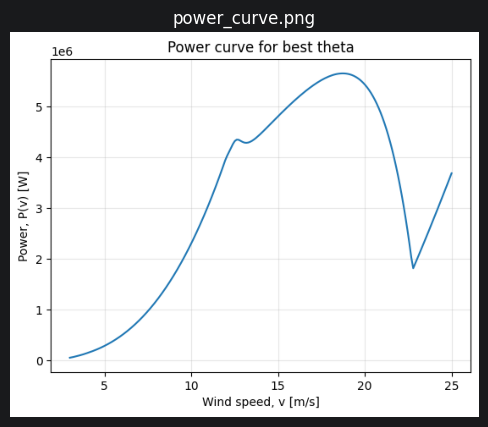

In [10]:
show_png("power_curve.png")

Мощность растет с увеличением скорости ветра до допустимого региона. Затем контроллер ограничивает дальнейший рост мощности. Небольшое превышение допустимой мощности допустимо в текущей постановке, потому что штрафы являются мягкими, а не жесткими ограничениями.

## Закон управления

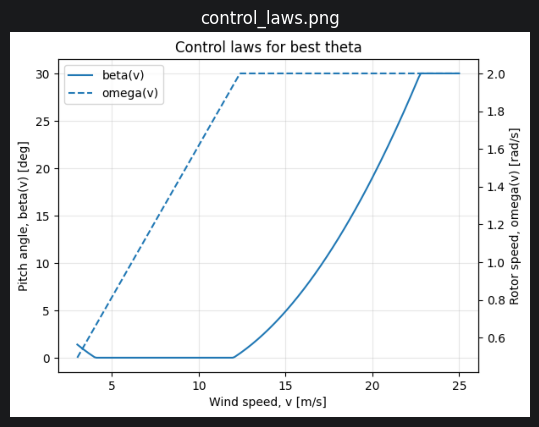

In [11]:
show_png("control_laws.png")

При умеренном ветре угол pitch почти нулевой, что позволяет извлекать больше энергии. При сильном ветре pitch быстро растет и ограничивает мощность. Скорость ротора сначала растет почти линейно, затем выходит на ограничение. В целом котроллер имеет физически осмысленное поведение.

## Итог

L-SHADE успешно сошелся на данной задаче. Адаптивный механизм для `F` и `CR` работали, внешний архив использовался, а линейная популяционное уменьшение корректно перевело оптимизацию от широкого поиска к локальной настройке. Найденный контроллер физически интерпретируем: он увеличивает мощность при умеренном ветре и ограничивает ее при сильном ветре. Поведение оптимайзера выглядит стабильным и воспроизводимым.

# Байзлайн Случайный поиск

Random Search используется как простой baseline. Он случайно выбирает параметры внутри допустимых границ и не использует информацию о форме целевого ландшафта. У метода нет адаптивного механизма, архива, кроссовера, истории успеха и динамики популяции. Поэтому он полезен как проверка: показывает, какого качества можно достичь простым случайным перебором при том же наборе параметров расчета.

## Загрузка результатов Random Search

In [12]:
RANDOM_FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "random_search"
RANDOM_SUMMARY_PATH = PROJECT_ROOT / "results" / "summary" / "random_search_summary.json"

assert RANDOM_FIGURES_DIR.exists(), f"Не найдена папка с графиками: {RANDOM_FIGURES_DIR}"
assert RANDOM_SUMMARY_PATH.exists(), f"Не найден summary JSON: {RANDOM_SUMMARY_PATH}"

with RANDOM_SUMMARY_PATH.open("r", encoding="utf-8") as file:
    random_summary = json.load(file)

random_figures = sorted(RANDOM_FIGURES_DIR.glob("*.png"))
random_figures

[WindowsPath('C:/Users/oljjago/PycharmProjects/PMO_2_2026/results/figures/random_search/control_laws.png'),
 WindowsPath('C:/Users/oljjago/PycharmProjects/PMO_2_2026/results/figures/random_search/convergence.png'),
 WindowsPath('C:/Users/oljjago/PycharmProjects/PMO_2_2026/results/figures/random_search/power_curve.png')]

## Основные результаты baseline

In [13]:
display(Markdown(f"""
| Метрика | Значение |
|---|---:|
| best_final_J | `{random_summary['best_final_J']:.6f}` |
| theta_best | `{random_summary['theta_best']}` |
| runtime_sec | `{random_summary['runtime_sec']:.3f}` |
| max_power_MW | `{random_summary['max_power_MW']:.3f}` |
| n_runs | `{random_summary['n_runs']}` |
| max_evals | `{random_summary['max_evals']}` |
"""))


| Метрика | Значение |
|---|---:|
| best_final_J | `-0.280814` |
| theta_best | `[0.527995925078022, 1.1908841703745985, 0.09941736829390857, 0.312623441747351, 0.1261847033071951]` |
| runtime_sec | `1.044` |
| max_power_MW | `6.187` |
| n_runs | `15` |
| max_evals | `5000` |


## Графики Random Search

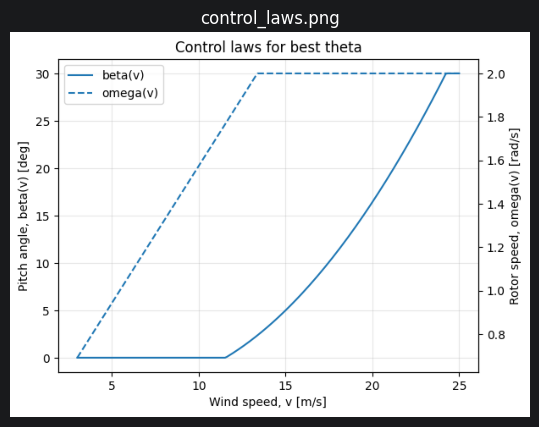

Контроль управления показывают форму найденных зависимостей beta(v) и omega(v). Эти зависимости появились без направленной адаптации, только через случайный перебор параметров внутри граничных условий.

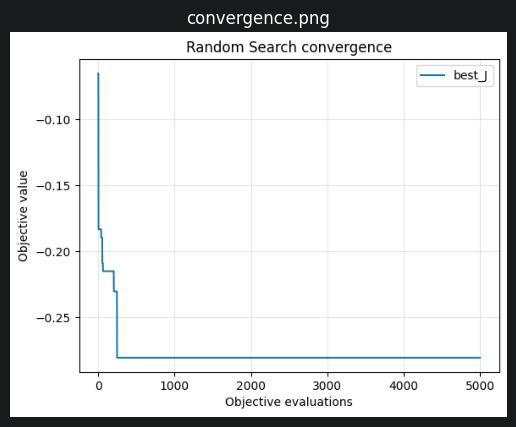

Улучшение происходит за счет случайных удачных попаданий в хорошие области. Поэтому convergence менее структурированный, чем у L-SHADE: нет направленного движения популяций и нет использования успешных шагов.

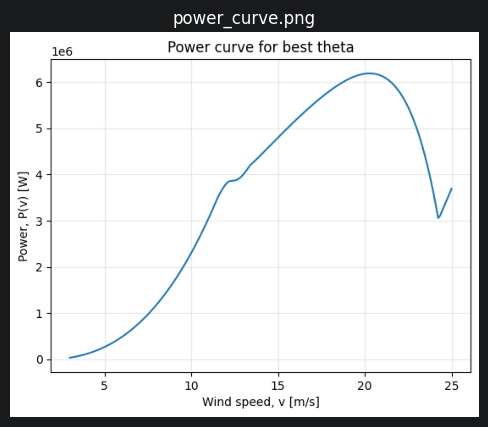

Кривая мощности показывает поведение контроллера, найденного случайным поиском. Мощность растет с скоростью ветра, а затем ограничивается параметрами управления и штрафами целевой функции.

In [15]:
random_explanations = {
    "convergence.png": "Улучшение происходит за счет случайных удачных попаданий в хорошие области. Поэтому convergence менее структурированный, чем у L-SHADE: нет направленного движения популяций и нет использования успешных шагов.",
    "power_curve.png": "Кривая мощности показывает поведение контроллера, найденного случайным поиском. Мощность растет с скоростью ветра, а затем ограничивается параметрами управления и штрафами целевой функции.",
    "control_laws.png": "Контроль управления показывают форму найденных зависимостей beta(v) и omega(v). Эти зависимости появились без направленной адаптации, только через случайный перебор параметров внутри граничных условий.",
}

for figure_path in random_figures:
    image = Image.open(figure_path)
    plt.figure(figsize=(10, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(figure_path.name)
    plt.show()
    display(Markdown(random_explanations.get(
        figure_path.name,
        "График используется для визуальной проверки поведения baseline."
    )))

# Сравнение L-SHADE и Random Search

Random Search не использует информацию о хороших решениях: каждый новый кандидат выбирается независимо. L-SHADE работает иначе: он использует динамику популяции, масштаб адаптивной мутации, кроссовер, внешний архив, историю успеха и линейное уменьшение популяции.

Обе оптимизации выполнялись при одинаковом `max_evals` и одинаковых seeds из одного конфига эксперимента. На графиках видно, что L-SHADE дает более структурированное поведение ковершенции: поиск становится направленным, популяция постепенно сжимается, а адаптивный механизм используют удачные шаги предыдущих генераций.

Random Search полезен как baseline, но его улучшения зависят от случайных попаданий. L-SHADE лучше подходит для такой задачи, потому что постепенно переходит от exploration к exploitation и формирует более интерпретируемый контроллер.

# Общий вывод по проекту

Задача робастной настройки управления ветротурбиной является шумной оптимизацией по типу "черного ящика": целевая функция зависит от случайного ветра и физической модели, а явных градиентов нет. Параметризованный контроллер упрощает задачу до поиска нескольких интерпретируемых параметров.

L-SHADE оказался подходящим методом для этой постановки. Adaptive Differential Evolution устойчиво работает со стохастической целевой функцией, граничными условиями и мягкими штрафами. В результате оптимизатор сошелся стабильно, использовал адаптивный механизм и уменьшение популяции, а найденное управление получилось физически осмысленным.